# Long term data preparation for event study

# Tweets and financial markets

## Group Project

Cathy (Cui) Yu, Hefei Mao, Yichi Wang, Di Yang, Marc Hayes

### Imports

In [1]:
import glob
import os
import re
from pathlib import Path
from typing import List, Optional, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
INPUT_DIR_CSV = "DATA EOD"

csv_files = [f for f in os.listdir(INPUT_DIR_CSV) if f.endswith(".csv")]
csv_files.remove("tickers.csv")  # remove the tickers.csv, which is only an overview

print(f"Loaded {len(csv_files)} CSV files: {csv_files[:3]} ... {csv_files[-3:]}.")

Loaded 50 CSV files: ['AAL.csv', 'AAPL.csv', 'AMD.csv'] ... ['UAL.csv', 'VMC.csv', 'XOM.csv'].


### Loading the twitter data

In [3]:
df_tweets = pd.read_csv("tweets_event_windows_final.csv")
df_tweets.head()

,new_id,id,text,date,event_minute,ticker,company_name,industry,event_time_et,in_trading_hours,adjusted_event_time_et,adjusted_event_time_utc,event_1h_pre_et,event_1h_end_et,event_5d_pre_et,event_5d_end_et,event_1h_pre,event_1h_end,event_5d_pre,event_5d_end
0,52,911287725847908352,Thank you to Doug Parker and American Airlines...,2017-09-22 17:54:59,2017-09-22 17:54:00+00:00,AAL,American Airlines Group,Airlines & Travel,2017-09-22 13:54:00-04:00,0,2017-09-22 13:54:00-04:00,2017-09-22 17:54:00+00:00,2017-09-22 12:54:00-04:00,2017-09-22 14:54:00-04:00,2017-09-15 09:30:00-04:00,2017-09-29 09:30:00-04:00,2017-09-22 16:54:00+00:00,2017-09-22 18:54:00+00:00,2017-09-15 13:30:00+00:00,2017-09-29 13:30:00+00:00
1,149,1184147319480041473,"Join me in Dallas, Texas this Thursday (Octobe...",2019-10-15 16:41:36,2019-10-15 16:41:00+00:00,AAL,American Airlines Group,Airlines & Travel,2019-10-15 12:41:00-04:00,0,2019-10-15 12:41:00-04:00,2019-10-15 16:41:00+00:00,2019-10-15 11:41:00-04:00,2019-10-15 13:41:00-04:00,2019-10-08 09:30:00-04:00,2019-10-22 09:30:00-04:00,2019-10-15 15:41:00+00:00,2019-10-15 17:41:00+00:00,2019-10-08 13:30:00+00:00,2019-10-22 13:30:00+00:00
2,148,1184631273454817280,"THANK YOU you Dallas, Texas. See you tomorrow ...",2019-10-17 00:44:39,2019-10-17 00:44:00+00:00,AAL,American Airlines Group,Airlines & Travel,2019-10-16 20:44:00-04:00,1,2019-10-17 09:30:00-04:00,2019-10-17 13:30:00+00:00,2019-10-17 08:30:00-04:00,2019-10-17 10:30:00-04:00,2019-10-10 09:30:00-04:00,2019-10-24 09:30:00-04:00,2019-10-17 12:30:00+00:00,2019-10-17 14:30:00+00:00,2019-10-10 13:30:00+00:00,2019-10-24 13:30:00+00:00
3,147,1184987864125321216,Just arrived at the American Airlines Center i...,2019-10-18 00:21:37,2019-10-18 00:21:00+00:00,AAL,American Airlines Group,Airlines & Travel,2019-10-17 20:21:00-04:00,1,2019-10-18 09:30:00-04:00,2019-10-18 13:30:00+00:00,2019-10-18 08:30:00-04:00,2019-10-18 10:30:00-04:00,2019-10-11 09:30:00-04:00,2019-10-25 09:30:00-04:00,2019-10-18 12:30:00+00:00,2019-10-18 14:30:00+00:00,2019-10-11 13:30:00+00:00,2019-10-25 13:30:00+00:00
4,24,700795170023825408,"I use both iPhone &amp, Samsung. If Apple does...",2016-02-19 21:32:43,2016-02-19 21:32:00+00:00,AAPL,Apple Inc.,Technology & Internet,2016-02-19 16:32:00-05:00,1,2016-02-22 09:30:00-05:00,2016-02-22 14:30:00+00:00,2016-02-22 08:30:00-05:00,2016-02-22 10:30:00-05:00,2016-02-12 09:30:00-05:00,2016-02-29 09:30:00-05:00,2016-02-22 13:30:00+00:00,2016-02-22 15:30:00+00:00,2016-02-12 14:30:00+00:00,2016-02-29 14:30:00+00:00


### Preprocessing twitter data

In [4]:
# For the long term analysis we focus on the daily stock metrics, so we will convert the datetime to day level

# Convert the "date" and "event_minute" column from string type to pandas timestamp
df_tweets["date"] = pd.to_datetime(df_tweets["date"], errors="coerce")
df_tweets["event_minute"] = pd.to_datetime(df_tweets["event_minute"], errors="coerce")

# Create a new column for the day level
df_tweets["event_day_utc"] = df_tweets["date"].dt.date

### Filtering the tweets to retain only relevant entries

In [5]:
df_tweets.columns

Index(['new_id', 'id', 'text', 'date', 'event_minute', 'ticker',
       'company_name', 'industry', 'event_time_et', 'in_trading_hours',
       'adjusted_event_time_et', 'adjusted_event_time_utc', 'event_1h_pre_et',
       'event_1h_end_et', 'event_5d_pre_et', 'event_5d_end_et', 'event_1h_pre',
       'event_1h_end', 'event_5d_pre', 'event_5d_end', 'event_day_utc'],
      dtype='object')

In [6]:
# Keep only the relevant columns for the long term analysis
df_tweets_filtered = df_tweets[[
    "id", 
    "text", 
    "date", 
    "event_day_utc", 
    "event_minute", 
    "ticker", 
    "company_name", 
    "industry"
]]
df_tweets_filtered.head()

,id,text,date,event_day_utc,event_minute,ticker,company_name,industry
0,911287725847908352,Thank you to Doug Parker and American Airlines...,2017-09-22 17:54:59,2017-09-22,2017-09-22 17:54:00+00:00,AAL,American Airlines Group,Airlines & Travel
1,1184147319480041473,"Join me in Dallas, Texas this Thursday (Octobe...",2019-10-15 16:41:36,2019-10-15,2019-10-15 16:41:00+00:00,AAL,American Airlines Group,Airlines & Travel
2,1184631273454817280,"THANK YOU you Dallas, Texas. See you tomorrow ...",2019-10-17 00:44:39,2019-10-17,2019-10-17 00:44:00+00:00,AAL,American Airlines Group,Airlines & Travel
3,1184987864125321216,Just arrived at the American Airlines Center i...,2019-10-18 00:21:37,2019-10-18,2019-10-18 00:21:00+00:00,AAL,American Airlines Group,Airlines & Travel
4,700795170023825408,"I use both iPhone &amp, Samsung. If Apple does...",2016-02-19 21:32:43,2016-02-19,2016-02-19 21:32:00+00:00,AAPL,Apple Inc.,Technology & Internet


### Processing the stock data

### Aggregation of Intraday Data to Daily Frequency

#### 1. Daily Open

The daily open is defined as the first observed price of the trading day:

$$
P^{open}_t = P_{t,1}
$$

---

#### 2. Daily Close

The daily close is defined as the last observed price of the trading day:

$$
P^{close}_t = P_{t,n_t}
$$

---

#### 3. Daily High

The daily high is the maximum observed price during the trading day:

$$
P^{high}_t = \max_{i=1,\dots,n_t} P_{t,i}
$$

---

#### 4. Daily Low

The daily low is the minimum observed price during the trading day:

$$
P^{low}_t = \min_{i=1,\dots,n_t} P_{t,i}
$$

---

#### 5. Typical Price (Intraday Approximation)

Since transaction-level data is not available, the typical price is used for VWAP computation:

$$
TP_{t,i} = \frac{H_{t,i} + L_{t,i} + C_{t,i}}{3}
$$

where:

- $H_{t,i}$ = high of minute $i$  
- $L_{t,i}$ = low of minute $i$  
- $C_{t,i}$ = close of minute $i$  

---

#### 6. Daily Volume

Daily volume is the sum of all intraday traded volumes:

$$
V_t = \sum_{i=1}^{n_t} V_{t,i}
$$

---

#### 7. Daily VWAP (Volume-Weighted Average Price)

$$
VWAP_t =
\frac{
\sum_{i=1}^{n_t} (TP_{t,i} \cdot V_{t,i})
}{
\sum_{i=1}^{n_t} V_{t,i}
}
$$

---

## 8. Daily Simple Return

The daily simple return is computed using closing prices:

$$
R_t =
\frac{
P^{close}_t - P^{close}_{t-1}
}{
P^{close}_{t-1}
}
$$

---

#### 9. Log Return (Optional)

$$
r_t =
\ln \left(
\frac{
P^{close}_t
}{
P^{close}_{t-1}
}
\right)
$$

---

This aggregation produces the daily dataset required for the estimation window and event window in the event study framework.

In [7]:
INPUT_DIR_CSV = "DATA EOD"

csv_files = [f for f in os.listdir(INPUT_DIR_CSV) if f.endswith(".csv")]
csv_files.remove("tickers.csv")  # remove the tickers.csv, which is only an overview

print(f"Loaded {len(csv_files)} CSV files: {csv_files[:3]} ... {csv_files[-3:]}.")

Loaded 50 CSV files: ['AAL.csv', 'AAPL.csv', 'AMD.csv'] ... ['UAL.csv', 'VMC.csv', 'XOM.csv'].


In [8]:
# Configure the output directory for the daily data
OUTPUT_DIR_DAILY = "DATA DAILY"

# Ensure directory exists
os.makedirs(OUTPUT_DIR_DAILY, exist_ok=True)

# Main processing loop
for file in csv_files:
    print(f"Processing file {file}")

    # Load file
    df = pd.read_csv(os.path.join(INPUT_DIR_CSV, file))

    # This assertion checks if the "timestamp" and "datetime" columns are identical for all rows in the DataFrame. 
    # If they are not, it will raise an AssertionError with the provided message.
    assert (df["timestamp"] == df["datetime"]).all(), \
        "The 'timestamp' and 'datetime' columns do not match for all rows."

    # Convert the column to datetime format if it is not already in that format
    if not pd.api.types.is_datetime64_any_dtype(df["timestamp"]):
        df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
    
    # From timestamp create a day level column
    df["day"] = df["timestamp"].dt.date

    # Step 1 — Make Sure Data Is Sorted
    df = df.sort_values("timestamp")

    # Step 2 — Compute Minute Typical Price (for VWAP)
    df["typical_price"] = (df["high"] + df["low"] + df["close"]) / 3

    # Step 3 — Group by Day and Aggregate
    df_daily = df.groupby("day").agg(
        daily_open=("open", "first"),          # first minute open
        daily_close=("close", "last"),         # last minute close
        daily_high=("high", "max"),            # highest high
        daily_low=("low", "min"),              # lowest low
        daily_volume=("volume", "sum")         # total volume
    ).reset_index()

    # # Step 4 — Compute Daily VWAP
    df["price_volume"] = df["typical_price"] * df["volume"]

    vwap = (
        df.groupby("day")
        .agg(
            pv_sum=("price_volume", "sum"),
            vol_sum=("volume", "sum")
        )
    )

    vwap["daily_vwap"] = vwap["pv_sum"] / vwap["vol_sum"]

    vwap = vwap[["daily_vwap"]].reset_index()

    df_daily = df_daily.merge(vwap, on="day")

    # Step 5 — Compute Daily Returns (Standard Simple Return & Log Return)
    df_daily = df_daily.sort_values("day")

    df_daily["daily_return"] = df_daily["daily_close"].pct_change()
    df_daily["log_return"] = np.log(df_daily["daily_close"] / df_daily["daily_close"].shift(1))

    # Write df_daily to new csv file in the daily output directory
    output_file = os.path.join(OUTPUT_DIR_DAILY, f"{file[:-4]}_daily.csv")
    df_daily.to_csv(output_file, index=False)
    print(f"Saved daily data to {output_file}\n")

Processing file AAL.csv
Saved daily data to DATA DAILY\AAL_daily.csv

Processing file AAPL.csv
Saved daily data to DATA DAILY\AAPL_daily.csv

Processing file AMD.csv
Saved daily data to DATA DAILY\AMD_daily.csv

Processing file AMZN.csv
Saved daily data to DATA DAILY\AMZN_daily.csv

Processing file APD.csv
Saved daily data to DATA DAILY\APD_daily.csv

Processing file APTV.csv
Saved daily data to DATA DAILY\APTV_daily.csv

Processing file AVGO.csv
Saved daily data to DATA DAILY\AVGO_daily.csv

Processing file BA.csv
Saved daily data to DATA DAILY\BA_daily.csv

Processing file BAC.csv
Saved daily data to DATA DAILY\BAC_daily.csv

Processing file BP.csv
Saved daily data to DATA DAILY\BP_daily.csv

Processing file BWA.csv
Saved daily data to DATA DAILY\BWA_daily.csv

Processing file C.csv
Saved daily data to DATA DAILY\C_daily.csv

Processing file CAT.csv
Saved daily data to DATA DAILY\CAT_daily.csv

Processing file CMI.csv
Saved daily data to DATA DAILY\CMI_daily.csv

Processing file COP.

### Retrieving the estimate + event window

#### For all 50 companies / tickers

In [9]:
def build_event_panel(
    tweet_id: int,
    df_tweets: pd.DataFrame,
    daily_dir: str = "DATA DAILY",
    tickers: Optional[List[str]] = None,
    file_pattern: str = "*_daily.csv",
    save_path: Optional[str] = None,
    est_days: int = 250,
    post_days: int = 10,
) -> Tuple[pd.DataFrame, dict]:
    """
    Construct a trading-day-aligned event-study panel for a single tweet.

    The function builds a master trading calendar from all available daily
    ticker CSV files and aligns the event window to trading days only.
    Weekends and market holidays are excluded automatically.

    Event-time alignment follows these rules:

    - The event date is taken from ``df_tweets["event_day_utc"]``.
    - t = 0 corresponds to the first trading day on or after the
      calendar event date.
    - t < 0 represents trading days prior to the event trading day.
    - t > 0 represents trading days after the event trading day.
    - All tickers share the same trading-day index.
    - If a ticker does not have data for a given trading day,
      the corresponding values are set to NaN.

    Each ticker contributes the following columns to the panel:

    - ``<TICKER>_daily_open``
    - ``<TICKER>_daily_close``
    - ``<TICKER>_daily_high``
    - ``<TICKER>_daily_low``
    - ``<TICKER>_daily_volume``
    - ``<TICKER>_daily_vwap``
    - ``<TICKER>_daily_return`` (if available)
    - ``<TICKER>_log_return`` (if available)

    Parameters
    ----------
    tweet_id : int
        Unique identifier of the tweet used as the event.
    df_tweets : pandas.DataFrame
        DataFrame containing tweet metadata. Must include columns:
        ``"id"`` and ``"event_day_utc"``.
    daily_dir : str, default="DATA DAILY"
        Directory containing daily ticker CSV files.
    tickers : list of str, optional
        Specific tickers to include. If None, all files matching
        ``file_pattern`` in ``daily_dir`` are used.
    file_pattern : str, default="*_daily.csv"
        Glob pattern used to identify ticker daily files.
    save_path : str, optional
        If provided, the resulting panel is saved to this path.
        Supports ".csv" and ".xlsx" formats.
    est_days : int, default=250
        Number of trading days in the estimation window prior to
        the event (t < 0).
    post_days : int, default=10
        Number of trading days in the post-event window (t > 0).

    Returns
    -------
    panel_df : pandas.DataFrame
        Trading-day-aligned event panel with columns:
        ``["t", "Day", <ticker-specific columns>]``.
        The column ``"t"`` represents event time in trading days.
        The column ``"Day"`` contains the corresponding trading dates
        in "YYYY-MM-DD" format.
    info : dict
        Dictionary containing diagnostic information, including:
        - event calendar date
        - event trading date
        - master calendar range
        - processed tickers
        - skipped files

    Notes
    -----
    - The master trading calendar is constructed from the union of
      all available ticker daily files.
    - The function assumes that daily CSV files were previously
      generated with a consistent schema.
    - No per-ticker date columns are created; a single shared
      trading-day column is used.
    - Missing trading days for individual tickers result in NaN values.
    - The function does not adjust for corporate actions or
      delistings.
    """
    # 1) lookup event day
    sel = df_tweets.loc[df_tweets["id"] == tweet_id, "event_day_utc"]
    if len(sel) == 0:
        raise KeyError(f"Tweet id {tweet_id} not found in df_tweets (expected column 'id').")
    event_day_ts = pd.to_datetime(sel.iloc[0]).normalize()
    event_day_str = event_day_ts.strftime("%Y-%m-%d")

    # 2) collect master trading calendar from available daily files
    if tickers is None:
        pattern = os.path.join(daily_dir, file_pattern)
        files = sorted(glob.glob(pattern))
    else:
        files = []
        for t in tickers:
            p = os.path.join(daily_dir, f"{t}_daily.csv")
            if os.path.exists(p):
                files.append(p)
            else:
                files.extend(glob.glob(os.path.join(daily_dir, f"{t}*_daily.csv")))
        files = sorted(set(files))

    if not files:
        raise FileNotFoundError(f"No daily files found in {daily_dir} matching pattern or tickers provided.")

    # gather all unique trading days seen in files
    all_days = set()
    for f in files:
        try:
            tmp = pd.read_csv(f, usecols=["day"])
        except Exception:
            try:
                tmp = pd.read_csv(f)
            except Exception:
                continue
            if "day" not in tmp.columns:
                continue
        parsed = pd.to_datetime(tmp["day"], errors="coerce").dt.strftime("%Y-%m-%d")
        parsed = parsed.dropna().unique()
        all_days.update(parsed.tolist())

    if len(all_days) == 0:
        raise RuntimeError("No valid trading dates found across daily files.")

    master_days = sorted(all_days)  # "YYYY-MM-DD" sorted lexicographically == chronological

    # 3) find event trading-day position: first trading day >= event_day_str
    try:
        ge_pos = next(i for i, d in enumerate(master_days) if d >= event_day_str)
    except StopIteration:
        raise RuntimeError(f"Event day {event_day_str} is after last trading day in master calendar.")

    # compute start/end positions on master calendar
    start_pos = ge_pos - est_days
    end_pos = ge_pos + post_days
    if start_pos < 0:
        start_pos = 0
    if end_pos >= len(master_days):
        end_pos = len(master_days) - 1

    window_days = master_days[start_pos:end_pos + 1]

    # build trading-day-aligned Day list mapped to t = -est_days..+post_days
    needed_len = est_days + post_days + 1
    t_values = list(range(-est_days, post_days + 1))
    zero_idx = est_days  # index in t_values for t == 0
    day_list = [None] * needed_len
    # place the available window_days into the correct slots relative to ge_pos
    for i, d in enumerate(window_days):
        pos_in_master = start_pos + i
        t_at_pos = pos_in_master - ge_pos  # e.g. -250 .. +10
        list_idx = zero_idx + t_at_pos
        if 0 <= list_idx < needed_len:
            day_list[list_idx] = d
    # panel skeleton
    panel_df = pd.DataFrame({"t": t_values, "Day": day_list})

    # 4) iterate tickers and reindex per trading-day list (exact trading-day alignment)
    processed = []
    skipped = []
    required_cols = [
        "daily_open", "daily_close", "daily_high",
        "daily_low", "daily_volume", "daily_vwap"
    ]
    optional_cols = ["daily_return", "log_return"]

    # build a list of days to lookup (strings, may contain None)
    lookup_days = list(panel_df["Day"].values)

    # 4) iterate tickers and collect columns first (avoid fragmentation)
    all_columns = {}

    processed = []
    skipped = []

    lookup_days = list(panel_df["Day"].values)

    for fpath in files:
        fname = os.path.basename(fpath)
        ticker = fname.split("_")[0]

        try:
            df = pd.read_csv(fpath)
        except Exception as e:
            print(f"Warning: couldn't read {fpath}: {e}. Skipping {ticker}.")
            skipped.append((ticker, "read_error"))
            continue

        if "day" not in df.columns:
            print(f"Skipping {ticker}: no 'day' column in {fname}.")
            skipped.append((ticker, "no_day"))
            continue

        df["day_str"] = pd.to_datetime(df["day"], errors="coerce").dt.strftime("%Y-%m-%d")
        df_indexed = df.set_index("day_str", drop=False)

        # Required + optional columns
        for col in required_cols + optional_cols:
            out_col = f"{ticker}_{col}"

            if col in df_indexed.columns:
                vals = [
                    df_indexed.at[d, col] if (d is not None and d in df_indexed.index)
                    else np.nan
                    for d in lookup_days
                ]
            else:
                vals = [np.nan] * len(lookup_days)

            all_columns[out_col] = vals

        processed.append(ticker)

    # 🔹 Single concat at the end (FAST + no fragmentation)
    panel_df = pd.concat([panel_df, pd.DataFrame(all_columns)], axis=1)

    info = {
        "event_day_calendar": event_day_str,
        "event_trading_day": master_days[ge_pos],
        "master_trading_days_count": len(master_days),
        "window_master_start": master_days[start_pos],
        "window_master_end": master_days[end_pos],
        "processed_tickers": processed,
        "skipped": skipped,
        "n_processed": len(processed),
        "n_skipped": len(skipped)
    }

    # 5) optional save; ensure directory exists
    if save_path:
        save_path = str(save_path)
        out_dir = os.path.dirname(save_path)
        if out_dir:
            os.makedirs(out_dir, exist_ok=True)
        if save_path.lower().endswith(".csv"):
            panel_df.to_csv(save_path, index=False)
        elif save_path.lower().endswith((".xls", ".xlsx")):
            panel_df.to_excel(save_path, index=False)
        else:
            panel_df.to_csv(save_path + ".csv", index=False)
        print(f"Wrote panel to {save_path}")

    return panel_df, info

In [10]:
# Example usage of the build_event_panel function for a specific tweet ID. 
# The resulting panel is saved to a CSV file, and diagnostic information is printed.
INPUT_DIR_COMPANY = "DATA DAILY"
OUTPUT_DIR_COMPANY = "EVENT STUDY PANELS BY COMPANY"
EXAMPLE_TWEET_ID = 911287725847908352

panel, info = build_event_panel(
    tweet_id=EXAMPLE_TWEET_ID,
    df_tweets=df_tweets,
    daily_dir=INPUT_DIR_COMPANY,
    save_path=f"{OUTPUT_DIR_COMPANY}/company_panel_tweet_id_{EXAMPLE_TWEET_ID}.csv"
)

print(info)
panel.head()

Wrote panel to EVENT STUDY PANELS BY COMPANY/company_panel_tweet_id_911287725847908352.csv
{'event_day_calendar': '2017-09-22', 'event_trading_day': '2017-09-22', 'master_trading_days_count': 3578, 'window_master_start': '2016-10-20', 'window_master_end': '2017-10-06', 'processed_tickers': ['AAL', 'AAPL', 'AMD', 'AMZN', 'APD', 'APTV', 'AVGO', 'BAC', 'BA', 'BP', 'BWA', 'CAT', 'CMI', 'COP', 'CVX', 'C', 'DAL', 'DD', 'DOW', 'ECL', 'FOXA', 'GCI', 'GD', 'GM', 'GOOGL', 'GS', 'IHRT', 'INTC', 'JPM', 'J', 'LIN', 'LMT', 'LUV', 'MAR', 'META', 'MLM', 'MSFT', 'MS', 'NOC', 'NVDA', 'NYT', 'OXY', 'PWR', 'QCOM', 'RTX', 'SBGI', 'TSLA', 'UAL', 'VMC', 'XOM'], 'skipped': [], 'n_processed': 50, 'n_skipped': 0}


,t,Day,AAL_daily_open,AAL_daily_close,AAL_daily_high,AAL_daily_low,AAL_daily_volume,AAL_daily_vwap,AAL_daily_return,AAL_log_return,...,VMC_daily_return,VMC_log_return,XOM_daily_open,XOM_daily_close,XOM_daily_high,XOM_daily_low,XOM_daily_volume,XOM_daily_vwap,XOM_daily_return,XOM_log_return
0,-250,2016-10-20,41.48,40.59,42.00,39.4148,14327702.0,40.262422,-0.014567,-0.014674,...,-0.002626,-0.002630,86.93,87.25,87.50,86.6000,6093537.0,87.113730,0.000918,0.000917
1,-249,2016-10-21,40.59,39.95,40.59,39.6500,9724946.0,39.904628,-0.015767,-0.015893,...,0.012620,0.012541,86.83,86.68,86.83,85.6985,9543695.0,86.266793,-0.006533,-0.006554
2,-248,2016-10-24,40.00,39.83,40.55,39.7700,6199339.0,40.043664,-0.003004,-0.003008,...,0.008428,0.008393,86.50,86.91,87.32,86.0700,7148454.0,86.757378,0.002653,0.002650
3,-247,2016-10-25,39.66,39.50,40.43,39.3600,5870714.0,39.865499,-0.008285,-0.008320,...,-0.012301,-0.012377,86.91,86.53,87.65,86.5000,6195693.0,86.950644,-0.004372,-0.004382
4,-246,2016-10-26,38.65,39.34,40.26,38.2100,9787074.0,39.162871,-0.004051,-0.004059,...,0.010024,0.009974,86.25,87.00,87.45,85.9500,7230735.0,86.814055,0.005432,0.005417


In [11]:
# Uncomment this to build panels for all tweets in the filtered DataFrame and save them to the specified directory.
OUTPUT_DIR_COMPANY = "EVENT STUDY PANELS BY COMPANY"


for id in df_tweets_filtered["id"].values:
    print("Processing tweet id:", id)
    panel, info = build_event_panel(
        tweet_id=id,
        df_tweets=df_tweets,
        daily_dir="DATA DAILY",
        save_path=f"{OUTPUT_DIR_COMPANY}/company_panel_tweet_id_{id}.csv"
    )

    print(info, "\n")

Processing tweet id: 911287725847908352
Wrote panel to EVENT STUDY PANELS BY COMPANY/company_panel_tweet_id_911287725847908352.csv
{'event_day_calendar': '2017-09-22', 'event_trading_day': '2017-09-22', 'master_trading_days_count': 3578, 'window_master_start': '2016-10-20', 'window_master_end': '2017-10-06', 'processed_tickers': ['AAL', 'AAPL', 'AMD', 'AMZN', 'APD', 'APTV', 'AVGO', 'BAC', 'BA', 'BP', 'BWA', 'CAT', 'CMI', 'COP', 'CVX', 'C', 'DAL', 'DD', 'DOW', 'ECL', 'FOXA', 'GCI', 'GD', 'GM', 'GOOGL', 'GS', 'IHRT', 'INTC', 'JPM', 'J', 'LIN', 'LMT', 'LUV', 'MAR', 'META', 'MLM', 'MSFT', 'MS', 'NOC', 'NVDA', 'NYT', 'OXY', 'PWR', 'QCOM', 'RTX', 'SBGI', 'TSLA', 'UAL', 'VMC', 'XOM'], 'skipped': [], 'n_processed': 50, 'n_skipped': 0} 

Processing tweet id: 1184147319480041473
Wrote panel to EVENT STUDY PANELS BY COMPANY/company_panel_tweet_id_1184147319480041473.csv
{'event_day_calendar': '2019-10-15', 'event_trading_day': '2019-10-15', 'master_trading_days_count': 3578, 'window_master_start'

#### Per industry

In [12]:
# Adjust these paths / names as needed
TICKER_MAP_XLSX = "tickers.xlsx"

def build_industry_panel_from_company_panel(panel_df: pd.DataFrame,
                                            mapping_path: str = TICKER_MAP_XLSX,
                                            industry_col_name: str = "Industry",
                                            ticker_col_name: str = "Ticker",
                                            how_return: str = "equal",   # "equal" or "volume"
                                            save_path: str = None) -> pd.DataFrame:
    """
    Build industry-aggregated panel from company-level panel_df.

    Parameters
    ----------
    panel_df : pd.DataFrame
        Company-level event panel produced by build_event_panel_tradingdays.
        Must contain columns like "<TICKER>_daily_close", "<TICKER>_daily_return",
        "<TICKER>_daily_vwap", "<TICKER>_daily_volume", etc.
        Also must contain 't' and 'Day' columns.
    mapping_path : str
        Path to an xlsx/csv file providing ticker -> industry mapping.
        The function expects two columns: ticker_col_name and industry_col_name.
    industry_col_name : str
        Column name in mapping file that contains industry/category.
    ticker_col_name : str
        Column name in mapping file that contains the ticker symbol.
    how_return : str
        How to aggregate returns: "equal" for equal-weighted average, "volume" for
        volume-weighted average (uses ticker daily volume).
    save_path : str or None
        If set, save the industry panel to this path as CSV or Excel.

    Returns
    -------
    industry_panel_df : pd.DataFrame
        DataFrame with same rows (t, Day) and one set of columns per industry:
          - <IND>_daily_return
          - <IND>_log_return
          - <IND>_daily_vwap
          - <IND>_daily_volume
          - <IND>_daily_close (volume-weighted)
          - <IND>_daily_open (volume-weighted)
        Missing values are NaN where appropriate.
    """

    # 1) load mapping
    if mapping_path.lower().endswith((".xls", ".xlsx")):
        mapping = pd.read_excel(mapping_path)
    else:
        mapping = pd.read_csv(mapping_path)

    if ticker_col_name not in mapping.columns or industry_col_name not in mapping.columns:
        raise KeyError(f"Mapping file must contain columns: {ticker_col_name}, {industry_col_name}")

    # Normalize ticker strings
    mapping[ticker_col_name] = mapping[ticker_col_name].astype(str).str.strip()

    # 2) detect tickers present in panel_df (by column prefix)
    # We expect columns like "AAL_daily_return", "AAL_daily_vwap", etc.
    cols = list(panel_df.columns)
    # Identify unique ticker prefixes by scanning columns that end with known suffixes:
    suffixes = ["_daily_close", "_daily_open", "_daily_vwap", "_daily_volume", "_daily_return", "_log_return"]
    suffixes = ["_daily_return", "_log_return"]
    tickers_in_panel = set()
    for c in cols:
        for suf in suffixes:
            if c.endswith(suf):
                tickers_in_panel.add(c[: -len(suf)])
    tickers_in_panel = sorted(tickers_in_panel)

    # 3) build mapping subset for present tickers
    mapping_sub = mapping[mapping[ticker_col_name].isin(tickers_in_panel)].copy()
    # warn about tickers not found in mapping
    missing_map = set(tickers_in_panel) - set(mapping_sub[ticker_col_name].tolist())
    if missing_map:
        print(f"Warning: {len(missing_map)} tickers found in panel but missing from mapping: {sorted(list(missing_map))[:10]} ...")

    # 4) build groups: industry -> list of tickers
    industry_groups = mapping_sub.groupby(industry_col_name)[ticker_col_name].apply(list).to_dict()

    # Prepare output skeleton: same t, Day
    df_industry = panel_df[["t", "Day"]].copy()

    # Helper to get a ticker-column name safely
    def col(ticker, suffix):
        return f"{ticker}_{suffix}"

    # For each industry compute aggregated series
    for industry, tickers in industry_groups.items():
        # keep only tickers that actually appear in the panel
        tickers = [t for t in tickers if t in tickers_in_panel]
        if len(tickers) == 0:
            continue

        # make arrays for values
        #  - volumes (sum)
        vol_cols = [col(t, "daily_volume") for t in tickers]
        vwap_cols = [col(t, "daily_vwap") for t in tickers]
        close_cols = [col(t, "daily_close") for t in tickers]
        open_cols = [col(t, "daily_open") for t in tickers]
        ret_cols = [col(t, "daily_return") for t in tickers]
        log_cols = [col(t, "log_return") for t in tickers]

        # Extract DataFrames (they will have NaNs where missing)
        vols_df = panel_df[vol_cols].astype(float) if vol_cols else pd.DataFrame(index=panel_df.index)
        vwaps_df = panel_df[vwap_cols].astype(float) if vwap_cols else pd.DataFrame(index=panel_df.index)
        closes_df = panel_df[close_cols].astype(float) if close_cols else pd.DataFrame(index=panel_df.index)
        opens_df = panel_df[open_cols].astype(float) if open_cols else pd.DataFrame(index=panel_df.index)
        rets_df = panel_df[ret_cols].astype(float) if ret_cols else pd.DataFrame(index=panel_df.index)
        logs_df = panel_df[log_cols].astype(float) if log_cols else pd.DataFrame(index=panel_df.index)

        # Volume: sum across tickers (NaN treated as 0 for summation of activity)
        # convert to numeric and treat NaN as 0 for volume sum
        vol_sum = vols_df.fillna(0).sum(axis=1)

        # VWAP: industry VWAP = sum(vwap_i * vol_i) / sum(vol_i)
        # compute numerator: sum_i (vwap_i * vol_i), ignoring pairs where either is NaN
        # we'll compute elementwise product then sum, treating NaN -> 0
        vwap_num = (vwaps_df.fillna(0) * vols_df.fillna(0)).sum(axis=1)
        # avoid div-by-zero
        industry_vwap = vwap_num.div(vol_sum).where(vol_sum != 0, np.nan)

        # Price aggregates (close/open): use volume-weighted close/open if available, else mean
        close_num = (closes_df.fillna(0) * vols_df.fillna(0)).sum(axis=1)
        industry_close = close_num.div(vol_sum).where(vol_sum != 0, np.nan)

        open_num = (opens_df.fillna(0) * vols_df.fillna(0)).sum(axis=1)
        industry_open = open_num.div(vol_sum).where(vol_sum != 0, np.nan)

        # Returns:
        if how_return == "equal":
            # simple average of tickers' returns (skip NaNs)
            industry_return = rets_df.mean(axis=1, skipna=True)
            industry_log_return = logs_df.mean(axis=1, skipna=True)
        elif how_return == "volume":
            # volume-weighted returns: sum(ret_i * vol_i) / sum(vol_i)
            # Note: if volumes are zero, falls back to NaN
            ret_num = (rets_df.fillna(0) * vols_df.fillna(0)).sum(axis=1)
            industry_return = ret_num.div(vol_sum).where(vol_sum != 0, np.nan)
            log_num = (logs_df.fillna(0) * vols_df.fillna(0)).sum(axis=1)
            industry_log_return = log_num.div(vol_sum).where(vol_sum != 0, np.nan)
        else:
            raise ValueError("how_return must be 'equal' or 'volume'")

        # Put into industry_df with tidy column names
        safe_ind = industry.replace(" ", "_").replace("/", "_")
        # df_industry[f"{safe_ind}_daily_volume"] = vol_sum.values
        # df_industry[f"{safe_ind}_daily_vwap"] = industry_vwap.values
        # df_industry[f"{safe_ind}_daily_close"] = industry_close.values
        # df_industry[f"{safe_ind}_daily_open"] = industry_open.values
        df_industry[f"{safe_ind}_daily_return"] = industry_return.values
        # df_industry[f"{safe_ind}_log_return"] = industry_log_return.values

    # 5) optionally save
    if save_path:
        os.makedirs(os.path.dirname(save_path) or ".", exist_ok=True)
        if save_path.lower().endswith(".csv"):
            df_industry.to_csv(save_path, index=False)
        elif save_path.lower().endswith((".xls", ".xlsx")):
            df_industry.to_excel(save_path, index=False)
        else:
            df_industry.to_csv(save_path + ".csv", index=False)
        print(f"Saved industry panel to {save_path}")

    return df_industry

# Example usage (run after you built panel_df):
industry_panel = build_industry_panel_from_company_panel(
    panel_df=panel,
    mapping_path="tickers.xlsx",
    industry_col_name="Industry",
    ticker_col_name="Ticker",
    how_return="equal",
    # save_path="EVENT STUDY PANELS BY INDUSTRY/example_industry_panel.csv",  # Uncomment if you want this saved
)

industry_panel.head()

,t,Day,Airlines_&_Travel_daily_return,Automobiles_&_Auto_Components_daily_return,Chemicals_(Materials_sector)_daily_return,Construction_&_Infrastructure_daily_return,Defense_&_Aerospace_daily_return,Financials_(Banks)_daily_return,News_&_Publishing_daily_return,Oil_&_Natural_Gas_daily_return,Semiconductors_(Information_Technology_sector)_daily_return,Technology_&_Internet_daily_return
0,-250,2016-04-01,-0.023924,-0.009562,0.008409,0.008197,0.003974,0.012415,0.014819,-0.010071,0.004896,0.008993
1,-249,2016-04-04,-0.006481,-0.023259,-0.010493,-0.013141,0.001018,-0.011133,-0.003518,-0.006407,-0.007563,-0.008595
2,-248,2016-04-05,-0.006387,0.021420,-0.003480,-0.000958,0.004246,-0.014890,-0.003740,-0.000925,-0.006467,-0.006779
3,-247,2016-04-06,-0.003292,0.001226,0.008231,0.010157,0.004184,0.001540,0.013406,0.017077,0.009228,0.013636
4,-246,2016-04-07,-0.018083,-0.022588,-0.013656,-0.014764,-0.005880,-0.032294,-0.013376,-0.007142,-0.022909,-0.014351


In [13]:
# Iterate over all company-level panels in the "DATA DAILY" directory, build industry panels, and save them to the "DATA DAILY BY INDUSTRY" directory.

INPUT_DIR_INDUSTRY = "EVENT STUDY PANELS BY COMPANY"
OUTPUT_DIR_INDUSTRY = "EVENT STUDY PANELS BY INDUSTRY"
MAPPING_PATH = "tickers.xlsx"

os.makedirs(OUTPUT_DIR_INDUSTRY, exist_ok=True)

# find all event panel files (adjust pattern if needed)
panel_files = sorted(glob.glob(os.path.join(INPUT_DIR_INDUSTRY, "*.csv")))

print(f"Found {len(panel_files)} panel files to process.\n")

for file_path in panel_files:
    file_name = os.path.basename(file_path)
    print(f"Processing {file_name}...")
    new_file_name = file_name.replace("company", "industry")  # company_panel_tweet_id_123.csv -> industry_panel_tweet_id_123.csv

    try:
        panel_df = pd.read_csv(file_path)
    except Exception as e:
        print(f"  Skipping (read error): {e}")
        continue

    # Skip files that are not event panels (basic sanity check)
    if "t" not in panel_df.columns or "Day" not in panel_df.columns:
        print("  Skipping (not an event panel).")
        continue

    try:
        df_industry = build_industry_panel_from_company_panel(
            panel_df,
            mapping_path=MAPPING_PATH,
            industry_col_name="Industry",  # adjust if different
            ticker_col_name="Ticker",      # adjust if different
            how_return="equal",            # or "volume"
            save_path=None                 # we'll save manually below
        )
    except Exception as e:
        print(f"  Skipping (aggregation error): {e}")
        continue

    output_path = os.path.join(OUTPUT_DIR_INDUSTRY, new_file_name)
    df_industry.to_csv(output_path, index=False)

    print(f"  Saved to {output_path}\n")

print("Done.")

Found 228 panel files to process.

Processing company_panel_tweet_id_1000391997969092608.csv...
  Saved to EVENT STUDY PANELS BY INDUSTRY\industry_panel_tweet_id_1000391997969092608.csv

Processing company_panel_tweet_id_1010503423773507584.csv...
  Saved to EVENT STUDY PANELS BY INDUSTRY\industry_panel_tweet_id_1010503423773507584.csv

Processing company_panel_tweet_id_1015586529484443648.csv...
  Saved to EVENT STUDY PANELS BY INDUSTRY\industry_panel_tweet_id_1015586529484443648.csv

Processing company_panel_tweet_id_1019932691339399168.csv...
  Saved to EVENT STUDY PANELS BY INDUSTRY\industry_panel_tweet_id_1019932691339399168.csv

Processing company_panel_tweet_id_1021384752136409088.csv...
  Saved to EVENT STUDY PANELS BY INDUSTRY\industry_panel_tweet_id_1021384752136409088.csv

Processing company_panel_tweet_id_1021917767467982854.csv...
  Saved to EVENT STUDY PANELS BY INDUSTRY\industry_panel_tweet_id_1021917767467982854.csv

Processing company_panel_tweet_id_1023546197129224192

### Test Plotting

Note: This was just quickly generated to get a peak. Later on this can be modified to the preferred style or changed to an interactive plot library (plotly).

In [14]:
def plot_event_panel(panel_df, *,
                     plot_choice_priority=("daily_return", "daily_close", "daily_vwap"),
                     figsize=(12, 6),
                     title=None,
                     xlabel="t (event time)",
                     ylabel=None,
                     save_fig: str = None,
                     max_legend_items: int = 30):
    """
    Plot one series per ticker from the event panel DataFrame using `t` as x-axis.

    - panel_df: DataFrame returned by build_event_panel (must contain 't' column).
    - plot_choice_priority: tuple of suffixes to try in order to pick the series to plot per ticker.
    - figsize: figure size
    - title/xlabel/ylabel: strings for plot labels. ylabel is inferred from the chosen series if None.
    - save_fig: optional file path to save the figure (e.g. "plots/event_1234.png").
    - max_legend_items: if too many tickers, legend will be limited to this number for readability.
    """
    if "t" not in panel_df.columns:
        raise KeyError("panel_df must contain a 't' column for event time on the x-axis.")

    # identify tickers by scanning column names and extracting prefixes before '_' 
    colnames = [c for c in panel_df.columns if c != "t"]
    prefixes = set()
    for c in colnames:
        m = re.match(r"^([A-Za-z0-9\.\-]+)_", c)
        if m:
            prefixes.add(m.group(1))
    prefixes = sorted(prefixes)

    # prepare plot
    fig, ax = plt.subplots(figsize=figsize)

    plotted = []
    for ticker in prefixes:
        chosen_col = None
        for suf in plot_choice_priority:
            col = f"{ticker}_{suf}"
            if col in panel_df.columns:
                # skip if column exists but all NaN
                if panel_df[col].notna().any():
                    chosen_col = col
                    break
        if chosen_col is None:
            # nothing to plot for this ticker
            continue

        ax.plot(panel_df["t"], panel_df[chosen_col], label=ticker, linewidth=1)
        plotted.append((ticker, chosen_col))

    if not plotted:
        raise RuntimeError("No ticker series found to plot. Check panel_df columns or adjust plot_choice_priority.")

    # labels
    if title is None:
        title = f"Event-time series (chosen priority: {', '.join(plot_choice_priority)})"
    if ylabel is None:
        # infer from first plotted series
        ylabel = plotted[0][1]

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.axvline(0, color="k", linestyle="--", linewidth=0.8, alpha=0.7)  # event day marker
    ax.grid(True, linestyle="--", alpha=0.4)

    # legend handling: limit number of legend entries for readability
    if len(plotted) <= max_legend_items:
        ax.legend(loc="best", fontsize="small")
    else:
        # show first few in legend and print count
        legend_labels = [p[0] for p in plotted[:max_legend_items]]
        handles, labels = ax.get_legend_handles_labels()
        # keep only handles corresponding to first max_legend_items tickers
        keep_handles = [h for h, lab in zip(handles, labels) if lab in legend_labels]
        ax.legend(keep_handles, legend_labels, loc="best", fontsize="small")
        ax.text(0.01, -0.12, f"Plotted {len(plotted)} tickers; legend truncated to first {max_legend_items}.",
                transform=ax.transAxes, fontsize="x-small", va="top")

    plt.tight_layout()

    if save_fig:
        outdir = os.path.dirname(save_fig)
        if outdir:
            os.makedirs(outdir, exist_ok=True)
        plt.savefig(save_fig, dpi=300)
        print(f"Saved figure to {save_fig}")

    plt.show()
    return fig, ax

Saved figure to plots/event_1080088_returns.png


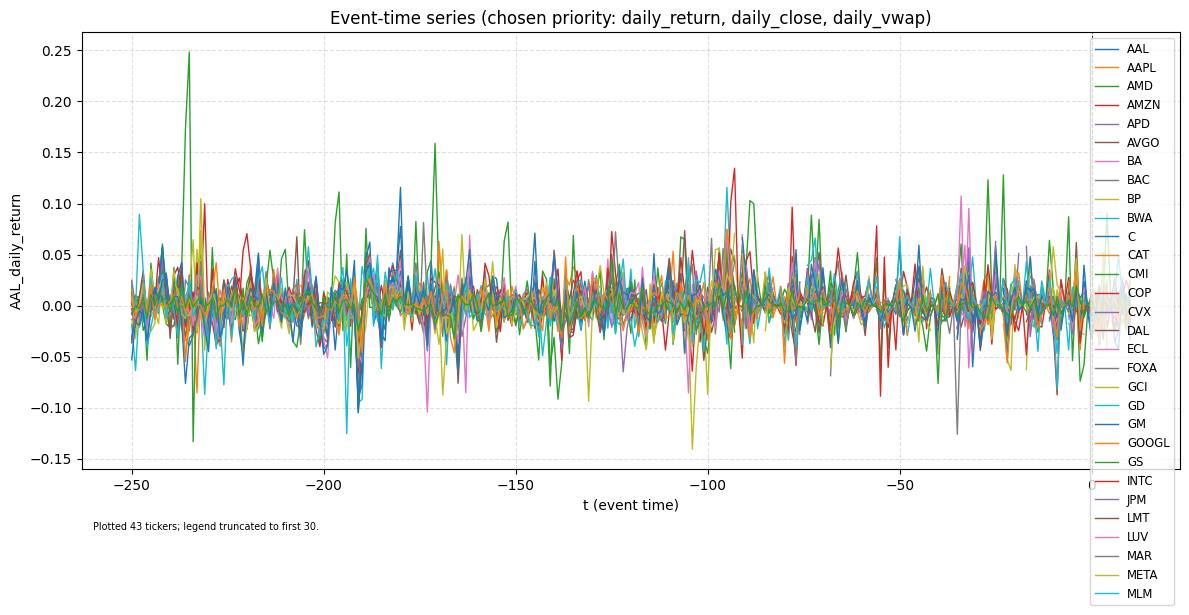

In [15]:
# Suppose panel_df is the DataFrame returned by build_event_panel(...)
fig, ax = plot_event_panel(panel, save_fig="plots/event_1080088_returns.png")

# Testing Code

In [16]:
# # Testing / Toy Example

# amd_stock_data = pd.read_csv(os.path.join(CSV_DIR, "AMD.csv"))
# amd_stock_data.head()

In [17]:
# # This assertion checks if the "timestamp" and "datetime" columns are identical for all rows in the DataFrame. 
# # If they are not, it will raise an AssertionError with the provided message.
# assert (amd_stock_data["timestamp"] == amd_stock_data["datetime"]).all(), \
#     "The 'timestamp' and 'datetime' columns do not match for all rows."

In [18]:
# # Assuming timestamp and datetime are identical, choose either column.
# # Check if the column is datetime type
# print(type(amd_stock_data["timestamp"][0]))
# print(type(amd_stock_data["datetime"][0]))

# # Convert the column to datetime format if it is not already in that format
# if not pd.api.types.is_datetime64_any_dtype(amd_stock_data["timestamp"]):
#     amd_stock_data["timestamp"] = pd.to_datetime(amd_stock_data["timestamp"], errors="coerce")

# print()
# print(type(amd_stock_data["timestamp"][0]))
# print(type(amd_stock_data["datetime"][0]))

In [19]:
# amd_stock_data.head()

In [20]:
# print(type(amd_stock_data["timestamp"][0]))
# print(type(amd_stock_data["datetime"][0]))

In [21]:
# # From timestamp create a day level column
# amd_stock_data["day"] = amd_stock_data["timestamp"].dt.date
# amd_stock_data.head()

In [22]:
# df = amd_stock_data.copy()

In [23]:
# # Step 1 — Make Sure Data Is Sorted
# df = df.sort_values("timestamp")

In [24]:
# # Step 2 — Compute Minute Typical Price (for VWAP)
# df["typical_price"] = (df["high"] + df["low"] + df["close"]) / 3

In [25]:
# # Step 3 — Group by Day and Aggregate
# df_daily = df.groupby("day").agg(
#     daily_open=("open", "first"),          # first minute open
#     daily_close=("close", "last"),         # last minute close
#     daily_high=("high", "max"),            # highest high
#     daily_low=("low", "min"),              # lowest low
#     daily_volume=("volume", "sum")         # total volume
# ).reset_index()

In [26]:
# # # Step 4 — Compute Daily VWAP
# df["price_volume"] = df["typical_price"] * df["volume"]

# vwap = (
#     df.groupby("day")
#       .agg(
#           pv_sum=("price_volume", "sum"),
#           vol_sum=("volume", "sum")
#       )
# )

# vwap["daily_vwap"] = vwap["pv_sum"] / vwap["vol_sum"]

# vwap = vwap[["daily_vwap"]].reset_index()

# df_daily = df_daily.merge(vwap, on="day")

In [27]:
# # Step 5 — Compute Daily Return (Standard Simple Return)
# df_daily = df_daily.sort_values("day")

# df_daily["daily_return"] = df_daily["daily_close"].pct_change()
# df_daily["log_return"] = np.log(df_daily["daily_close"] / df_daily["daily_close"].shift(1))

In [28]:
# df_daily

---

In [29]:
# Create DataFrame with only tweet id and matched industries list
df_tweet_id_industries = df_tweets_filtered[["id", "industry"]]

industry_panel_files = sorted(glob.glob(os.path.join(OUTPUT_DIR_INDUSTRY, "*.csv")))

df_panel_paths = pd.DataFrame({
    "panel_path": industry_panel_files
})

# extract id from filename
df_panel_paths["id"] = (
    df_panel_paths["panel_path"]
    .apply(lambda x: os.path.splitext(os.path.basename(x))[0].split("_")[-1])
    .astype("int64")   # important: match dtype with tweet id
)

# Merge both DataFrames
df_tweet_id_industries = df_tweet_id_industries.merge(
    df_panel_paths,
    on="id",
    how="left"
)
df_tweet_id_industries.head()

,id,industry,panel_path
0,911287725847908352,Airlines & Travel,EVENT STUDY PANELS BY INDUSTRY\industry_panel_...
1,1184147319480041473,Airlines & Travel,EVENT STUDY PANELS BY INDUSTRY\industry_panel_...
2,1184631273454817280,Airlines & Travel,EVENT STUDY PANELS BY INDUSTRY\industry_panel_...
3,1184987864125321216,Airlines & Travel,EVENT STUDY PANELS BY INDUSTRY\industry_panel_...
4,700795170023825408,Technology & Internet,EVENT STUDY PANELS BY INDUSTRY\industry_panel_...


In [30]:
df_tweets_filtered["industry"].value_counts()

industry
Technology & Internet            91
News & Publishing                91
Semiconductors                   16
Automobiles & Auto Components    14
Defense & Aerospace              11
Airlines & Travel                 6
Financials (Banks)                6
Construction & Infrastructure     1
Chemicals                         1
Oil & Natural Gas                 1
Name: count, dtype: int64

In [31]:
# Specify output directory and ensure it exists
OUTPUT_DIR_INDUSTRY_SINGLE = "EVENT STUDY PANELS BY SINGLE INDUSTRY"
os.makedirs(OUTPUT_DIR_INDUSTRY_SINGLE, exist_ok=True)

# Iterate over all tweet ids
for idx, row in df_tweet_id_industries.iterrows():
    # Get tweet id and industries list
    # tweet_id = row["id"]
    industry = row["industry"]

    # for industry in industries_list:
        # Load the industry panel
    try:
        df = pd.read_csv(row["panel_path"])
    except Exception as e:
        print(f"  Skipping (read error): {e}")
        continue

    # Get the industry specific daily return column (name)
    if industry == "Chemicals":
        rel_col_name = "Chemicals_(Materials_sector)_daily_return"
    elif industry == "Semiconductors":
        rel_col_name = "Semiconductors_(Information_Technology_sector)_daily_return"
    else:
        rel_col_name = industry.replace(" ", "_") + "_daily_return"

    # Filter the df
    df = df[["t", "Day", rel_col_name]]

    # Replace NaN values in return column with 0.0
    df[rel_col_name] = df[rel_col_name].fillna(0.0)

    # Construct output filename by replacing the generic "industry" tag
    # with the 4-letter abbreviation of the matched industry
    new_file_name = os.path.basename(row["panel_path"]).replace("industry", industry[:4].strip(), 1)
    output_path = Path(OUTPUT_DIR_INDUSTRY_SINGLE) / new_file_name

    # Write to new directory
    df.to_csv(output_path, index=False)

print(f"{len(df_tweet_id_industries)} csv files modified and saved in dir {OUTPUT_DIR_INDUSTRY_SINGLE}.")
print("Final DataFrame preview as example:")
display(df)

238 csv files modified and saved in dir EVENT STUDY PANELS BY SINGLE INDUSTRY.
Final DataFrame preview as example:


,t,Day,Oil_&_Natural_Gas_daily_return
0,-250,2016-04-01,-0.010071
1,-249,2016-04-04,-0.006407
2,-248,2016-04-05,-0.000925
3,-247,2016-04-06,0.017077
4,-246,2016-04-07,-0.007142
...,...,...,...
256,6,2017-03-13,-0.000443
257,7,2017-03-14,-0.008571
258,8,2017-03-15,0.012741
259,9,2017-03-16,-0.002889
